**Student: Azizbek Ganiev (ID: 475150)**

<br> </br>
<font color='darkred' size = 7.5> <center>  <b> Quantitative strategies on high-frequency data </b> </center> </font>
<font color='darkred' size = 5> <center>  8. Applying pair trading strategies </center> </font>
<br>
<font size = 5> <center> prof. Piotr Wójcik </center> </font>
<br> 
<font size = 5> <center>  academic year 2025/2026 </center> </font>

In [2]:
# lets load the necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import quantstats as qs
import warnings
warnings.simplefilter(action="ignore", category=UserWarning)  # ignore warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)  # ignore runtime warnings
warnings.simplefilter(action="ignore", category=FutureWarning)  # ignore future warnings

# lets add the functions path to sys.path
import sys
sys.path.append('functions')

In [15]:
# We import 1-minute quotations for US stocks downloaded from Alpha Vantage
# for the period 2025-01-01 do 2025-09-30

# downloaded from the Internet
data_url = "http://coin.wne.uw.edu.pl/pwojcik/hfd/US_stocks.csv"

dataUSA = pd.read_csv(data_url, 
                      # try to parse column "timestamp" as dates/datetimes
                      parse_dates = ["timestamp"], 
                      # use column "timestamp" as dataframe index
                      index_col = "timestamp")

dataUSA.head()

# open, high, low, close prices and volume for 14 companies:
# AAPL: Apple Co.
# META: Meta Platforms Inc.
# GOOGL: Alphabet Inc. (Google)
# KO: Coca-Cola
# PEP: Pepsi Co.
# MSFT: Microsoft Corp.
# GM: General Motors Co.
# GE: General Electric Co.
# AMZN: Amazon.com Inc.
# TSLA: Tesla Inc.
# WMT: Walmart
# NVDA: Nvidia
# MA: Mastercard
# V: Visa


,open_AAPL,high_AAPL,low_AAPL,close_AAPL,volume_AAPL,open_META,high_META,low_META,close_META,volume_META,...,open_MA,high_MA,low_MA,close_MA,volume_MA,open_V,high_V,low_V,close_V,volume_V
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-02 09:31:00,248.3506,248.4105,247.4327,247.6023,1245220,588.7706,591.9455,588.1616,591.9156,209802.0,...,526.1993,526.1993,523.6041,524.7426,48309.0,316.7216,316.9708,316.1435,316.8013,122361.0
2025-01-02 09:32:00,247.6672,248.5202,246.7044,247.0636,463134,591.7708,591.9905,589.9987,591.6660,36859.0,...,525.0856,525.1453,523.6538,523.6538,7293.0,316.9658,317.0405,316.0440,316.4724,17787.0
2025-01-02 09:33:00,246.9938,247.8218,246.6595,246.6845,219248,591.8657,592.5845,591.1892,592.0054,47969.0,...,524.1311,524.5686,523.2262,524.1012,8385.0,316.0439,316.4724,315.7748,316.1336,22212.0
2025-01-02 09:34:00,246.6546,246.7581,245.7966,246.2006,399303,591.9455,591.9455,589.5294,589.5491,53483.0,...,524.1112,524.1510,523.5693,523.8328,10321.0,316.1236,316.3827,315.8346,315.9542,14137.0
2025-01-02 09:35:00,246.1757,246.3652,245.7267,245.7567,289896,589.7690,590.2483,588.8207,588.9803,31812.0,...,523.8328,524.8371,523.8228,523.8974,10893.0,315.9442,316.9708,315.9442,316.5821,33400.0


In [19]:
# Let's create an object containing only closing prices
# (columns starting with "close_")

dataUSA_close = dataUSA.filter(like = "close_")

# fill missing data with the last non-missing value
# (forward fill method)

dataUSA_close.ffill(inplace = True)

C:\Users\LO79RS\AppData\Local\Temp\ipykernel_19576\2937512576.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataUSA_close.ffill(inplace = True)


In [21]:
# based on closing prices
# we will calculate logarithmic rates of return for
# all series in basis points (bps) 1bps = 0.01% = 0.0001,
# to obtain basis points of return, multiply by 10,000

# Shift index by desired number of periods - can be positive or negative
dataUSA_r = np.log(dataUSA_close / dataUSA_close.shift(1)) * 10000

# changing the column names to make them appropriate
# (replace close_ with r_ )

dataUSA_r.columns = [col.replace("close_", "r_") for col in dataUSA_r.columns]

dataUSA_r.head()

,r_AAPL,r_META,r_GOOGL,r_KO,r_PEP,r_MSFT,r_GM,r_GE,r_AMZN,r_TSLA,r_WMT,r_NVDA,r_MA,r_V
timestamp,,,,,,,,,,,,,,
2025-01-02 09:31:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:32:00,-21.780366,-4.217707,-39.375061,-12.796135,-17.946364,17.613405,-103.533312,-3.852733,35.620511,-86.852531,21.024466,85.055874,-20.770777,-10.387295
2025-01-02 09:33:00,-15.356011,5.734700,-11.580967,1.606497,0.000000,-33.751244,1.883721,-19.874932,-21.329295,-17.358192,-8.849361,-10.912782,8.540165,-10.711249
2025-01-02 09:34:00,-19.635414,-41.577490,-41.426502,-3.197022,5.892306,-16.623494,-13.250658,2.968295,-66.246771,-83.584442,-6.853629,-48.311828,-5.122460,-5.676427
2025-01-02 09:35:00,-18.046287,-9.652709,-0.265055,8.793406,1.634283,-0.471437,-14.393800,18.390916,-13.541575,-15.439169,4.083815,-13.013487,1.233142,19.853413


## Sample analysis for Coca-Cola and Pepsi stocks

In [22]:
# lets create an object with selected columns (needed for analyses)
# only closing prices and rates of return for KO and PEP

dataUSA_KO_PEP = pd.concat(
    [dataUSA_close[['close_KO', 'close_PEP']], 
     dataUSA_r[['r_KO', 'r_PEP']]],
    axis=1
)

dataUSA_KO_PEP.head()

,close_KO,close_PEP,r_KO,r_PEP
timestamp,,,,
2025-01-02 09:31:00,61.6987,150.0814,NaN,NaN
2025-01-02 09:32:00,61.6198,149.8123,-12.796135,-17.946364
2025-01-02 09:33:00,61.6297,149.8123,1.606497,0.000000
2025-01-02 09:34:00,61.6100,149.9006,-3.197022,5.892306
2025-01-02 09:35:00,61.6642,149.9251,8.793406,1.634283


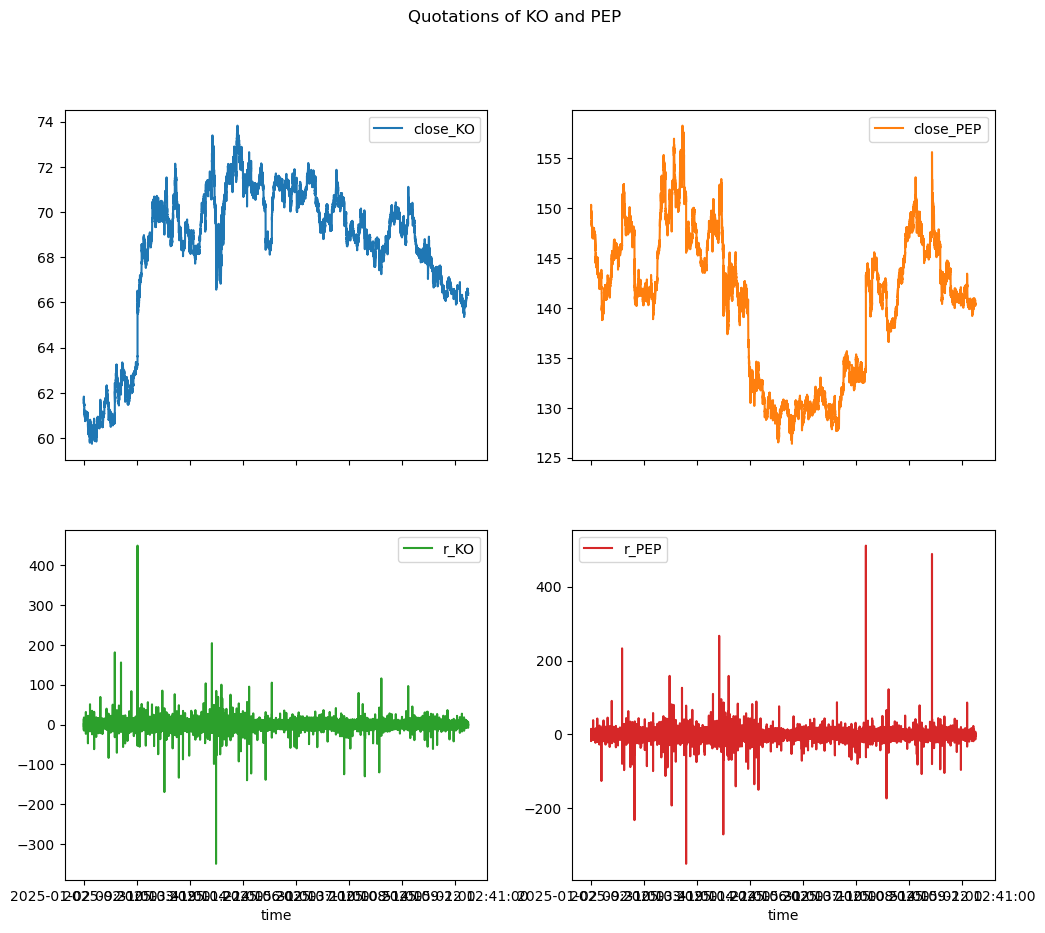

In [23]:
# lets see a figure of all columns
# with closing prices and returns for KO and PEP

# We don't want to treat time as a continuous variable in the graph
# (because there are "holes" from 4:00 PM to 9:30 AM the next day)

# Let's convert the datetime index to a text index and pass it as the x-axis
dataUSA_KO_PEP_plot = dataUSA_KO_PEP.copy()
dataUSA_KO_PEP_plot['time'] = dataUSA_KO_PEP_plot.index.astype(str)

# We reset the index to make 'time' a column
dataUSA_KO_PEP_plot = dataUSA_KO_PEP_plot.reset_index(drop = True)

# Let's set time as the X-axis and draw the graphs
dataUSA_KO_PEP_plot.plot(
    x = 'time',
    subplots = True,
    layout = (2, 2),
    title = "Quotations of KO and PEP",
    figsize = (12, 10)
)
plt.show()

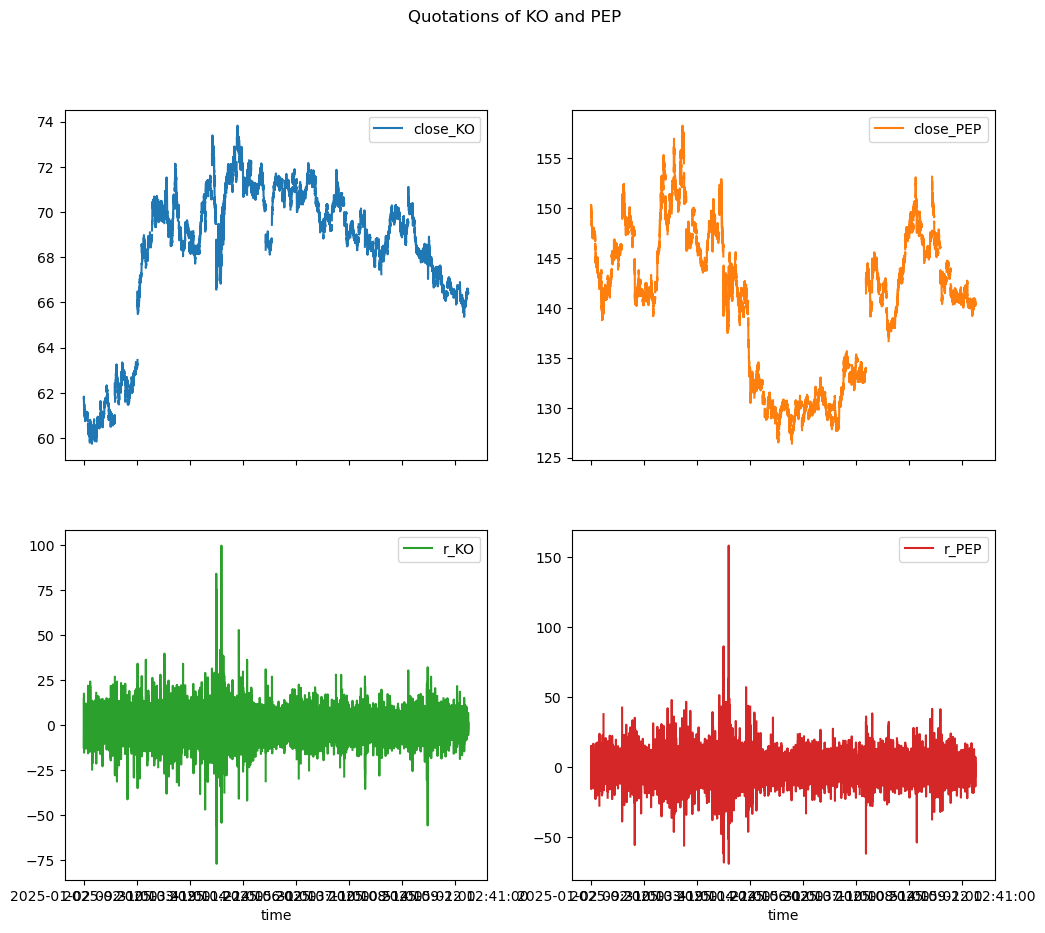

In [24]:
# initial assumptions about

# assumption 1
# we do not use the first 5 minutes of the session (9:31-9:35)
# and the last 5 minutes before the break (15:56-16:00) 
# let's insert missing data there

dataUSA_KO_PEP.loc[dataUSA_KO_PEP.between_time("9:31", "9:35").index] = np.nan
dataUSA_KO_PEP.loc[dataUSA_KO_PEP.between_time("15:56", "16:00").index] = np.nan

# and make the plots again

# Let's convert the datetime index to a text index and pass it as the x-axis
dataUSA_KO_PEP_plot = dataUSA_KO_PEP.copy()
dataUSA_KO_PEP_plot['time'] = dataUSA_KO_PEP_plot.index.astype(str)

# We reset the index to make 'time' a column
dataUSA_KO_PEP_plot = dataUSA_KO_PEP_plot.reset_index(drop = True)

# Let's set time as the X-axis and draw the graphs
dataUSA_KO_PEP_plot.plot(
    x = 'time',
    subplots = True,
    layout = (2, 2),
    title = "Quotations of KO and PEP",
    figsize = (12, 10)
)
plt.show()

# most of the outliers in returns disappeared

## Spread 1 based on prices

lets formulate a spread: `P1 - m * P2` (here `P_KO - m * P_PEP`)

where `m = m1/m2` is based on average ratio between the prices on the **PREVIOUS** day

Spread is a signal to our model, which shows whether to take position or not (volatility bands around the spread).

**CAUTION**! we assume the mean reverting behavior of the spread! 

We will calculate `m` based on **previous day's average prices**


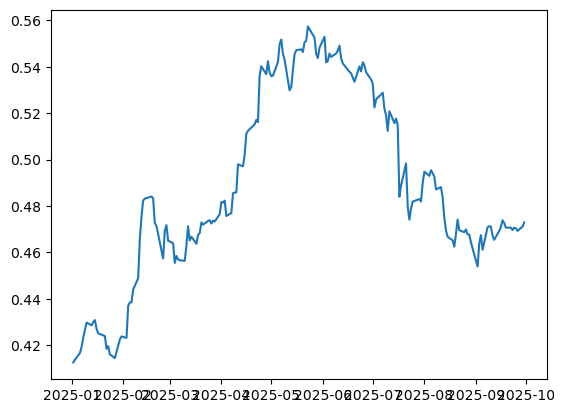

In [25]:
# lets calculate average ratio of prices on the daily basis

# Compute the ratio close_KO / close_PEP
ratio = dataUSA_KO_PEP["close_KO"] / dataUSA_KO_PEP["close_PEP"]

# Compute daily averages
US_av_ratio = ratio.resample("D").mean()
# keep non-missing values only
US_av_ratio = US_av_ratio.dropna()

# Assign the name
US_av_ratio = US_av_ratio.to_frame(name="av_ratio")

# Plot how the average ratio looks like
plt.plot(US_av_ratio.index, 
         US_av_ratio["av_ratio"])

# between 0.42 and 0.56


In [26]:
US_av_ratio.head()

,av_ratio
timestamp,
2025-01-02,0.412482
2025-01-03,0.413671
2025-01-06,0.416556
2025-01-07,0.419234
2025-01-08,0.423186


But calculations based on the first day will be used on the second day, etc.

Lets adjust the dataset accordingly by moving the time index to 9:30 of the next (trading) day.

In [27]:
# check first 10 dates
US_av_ratio.index[:10]

DatetimeIndex(['2025-01-02', '2025-01-03', '2025-01-06', '2025-01-07',
               '2025-01-08', '2025-01-10', '2025-01-13', '2025-01-14',
               '2025-01-15', '2025-01-16'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

In [28]:
# lets move it to 9:31 AM of the next day
US_av_ratio.index[:10] + pd.Timedelta("1D") + pd.Timedelta("9h31m")

DatetimeIndex(['2025-01-03 09:31:00', '2025-01-04 09:31:00',
               '2025-01-07 09:31:00', '2025-01-08 09:31:00',
               '2025-01-09 09:31:00', '2025-01-11 09:31:00',
               '2025-01-14 09:31:00', '2025-01-15 09:31:00',
               '2025-01-16 09:31:00', '2025-01-17 09:31:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

In [29]:
# but some of the dates might be Fridays and in this case
# we would move the index to 9:30 on Monday

# Lets check what days of the week are these original dates?

US_av_ratio.index[:10].day_name()

Index(['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday', 'Friday',
       'Monday', 'Tuesday', 'Wednesday', 'Thursday'],
      dtype='object', name='timestamp')

In [30]:
# lets use the above information to adjust the timestamps
US_av_ratio.index[:10] + pd.to_timedelta(np.where(US_av_ratio.index[:10].day_name() == "Friday", "3D", "1D")) + pd.Timedelta("9h31m")

# now it looks good

DatetimeIndex(['2025-01-03 09:31:00', '2025-01-06 09:31:00',
               '2025-01-07 09:31:00', '2025-01-08 09:31:00',
               '2025-01-09 09:31:00', '2025-01-13 09:31:00',
               '2025-01-14 09:31:00', '2025-01-15 09:31:00',
               '2025-01-16 09:31:00', '2025-01-17 09:31:00'],
              dtype='datetime64[ns]', freq=None)

In [31]:
# lets apply the changes in our data object
US_av_ratio.index = US_av_ratio.index + pd.to_timedelta(np.where(US_av_ratio.index.day_name() == "Friday", "3D", "1D")) + pd.Timedelta("9h31m")

US_av_ratio.head()

,av_ratio
2025-01-03 09:31:00,0.412482
2025-01-06 09:31:00,0.413671
2025-01-07 09:31:00,0.416556
2025-01-08 09:31:00,0.419234
2025-01-09 09:31:00,0.423186


## Spread 2 based on returns

alternative spread based on **RETURNS**:

`r1 - ms * r2` (here `r_KO - m * r_PEP`)

where `ms = s1/s2` is based on the ratio of **standard deviations** of returns on the **PREVIOUS** day

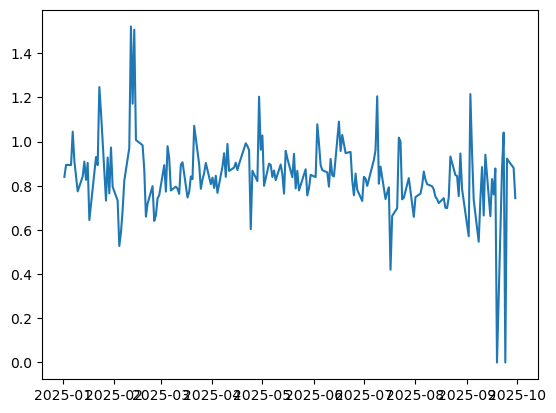

In [32]:
# Daily standard deviation ratio
US_sds_ratio = (
    dataUSA_KO_PEP
    .resample("D")
    .apply(lambda x: x["r_KO"].std() / x["r_PEP"].std())
    .to_frame(name = "sds_ratio")
)

# keep non-missing values only
US_sds_ratio = US_sds_ratio.dropna()

# see how it changes over time
plt.plot(US_sds_ratio.index, 
         US_sds_ratio["sds_ratio"])


In [33]:
# lets move the index to 9:31 of the next trading day

US_sds_ratio.index = US_sds_ratio.index + pd.to_timedelta(np.where(US_sds_ratio.index.day_name() == "Friday", "3D", "1D")) + pd.Timedelta("9h31m")

In [34]:
# we need to merge our basic 1 min data with daily calculations

dataUSA_2 = dataUSA_KO_PEP.copy()
dataUSA_2 = dataUSA_2.merge(US_av_ratio, 
                            # we want to use indexes 
                            # as merging keys
                            left_index = True, 
                            right_index = True, 
                            how = "left")
dataUSA_2 = dataUSA_2.merge(US_sds_ratio, 
                            left_index = True, 
                            right_index = True, 
                            how = "left")

# lets see how it worked

dataUSA_2.between_time("09:31", "09:40").head(30)

# there are a lot of missings in a the last 2 columns
# which should be filled with the last non-missing value
# (last multiplier is used until there is a new one)

,close_KO,close_PEP,r_KO,r_PEP,av_ratio,sds_ratio
timestamp,,,,,,
2025-01-02 09:31:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:32:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:33:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:34:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:35:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:36:00,61.7529,150.1457,14.374024,14.703199,NaN,NaN
2025-01-02 09:37:00,61.7480,150.0869,-0.793516,-3.916963,NaN,NaN
2025-01-02 09:38:00,61.8317,150.3124,13.545916,15.013353,NaN,NaN
2025-01-02 09:39:00,61.8219,150.1261,-1.585073,-12.401874,NaN,NaN


In [35]:
# We apply forward fill method to the last two columns
dataUSA_2[["av_ratio", "sds_ratio"]] = dataUSA_2[["av_ratio", "sds_ratio"]].ffill()

# and check the results
dataUSA_2.between_time("09:31", "09:40").head(30)

# now the values are filled properly

,close_KO,close_PEP,r_KO,r_PEP,av_ratio,sds_ratio
timestamp,,,,,,
2025-01-02 09:31:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:32:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:33:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:34:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:35:00,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02 09:36:00,61.7529,150.1457,14.374024,14.703199,NaN,NaN
2025-01-02 09:37:00,61.7480,150.0869,-0.793516,-3.916963,NaN,NaN
2025-01-02 09:38:00,61.8317,150.3124,13.545916,15.013353,NaN,NaN
2025-01-02 09:39:00,61.8219,150.1261,-1.585073,-12.401874,NaN,NaN


In [36]:
# lets make sure that we exclude weekends from our data

dataUSA_2.index.day_name().value_counts()

# there are no weekends in the data

timestamp
Tuesday      15210
Wednesday    14820
Thursday     14430
Friday       14430
Monday       13650
Name: count, dtype: int64

In [37]:
# now we can calculate the spread (in 2 variants)
dataUSA_2["spread_avratio"] = dataUSA_2["close_KO"] - dataUSA_2["av_ratio"] * dataUSA_2["close_PEP"]
dataUSA_2["spread_sdsratio"] = dataUSA_2["r_KO"] - dataUSA_2["sds_ratio"] * dataUSA_2["r_PEP"]

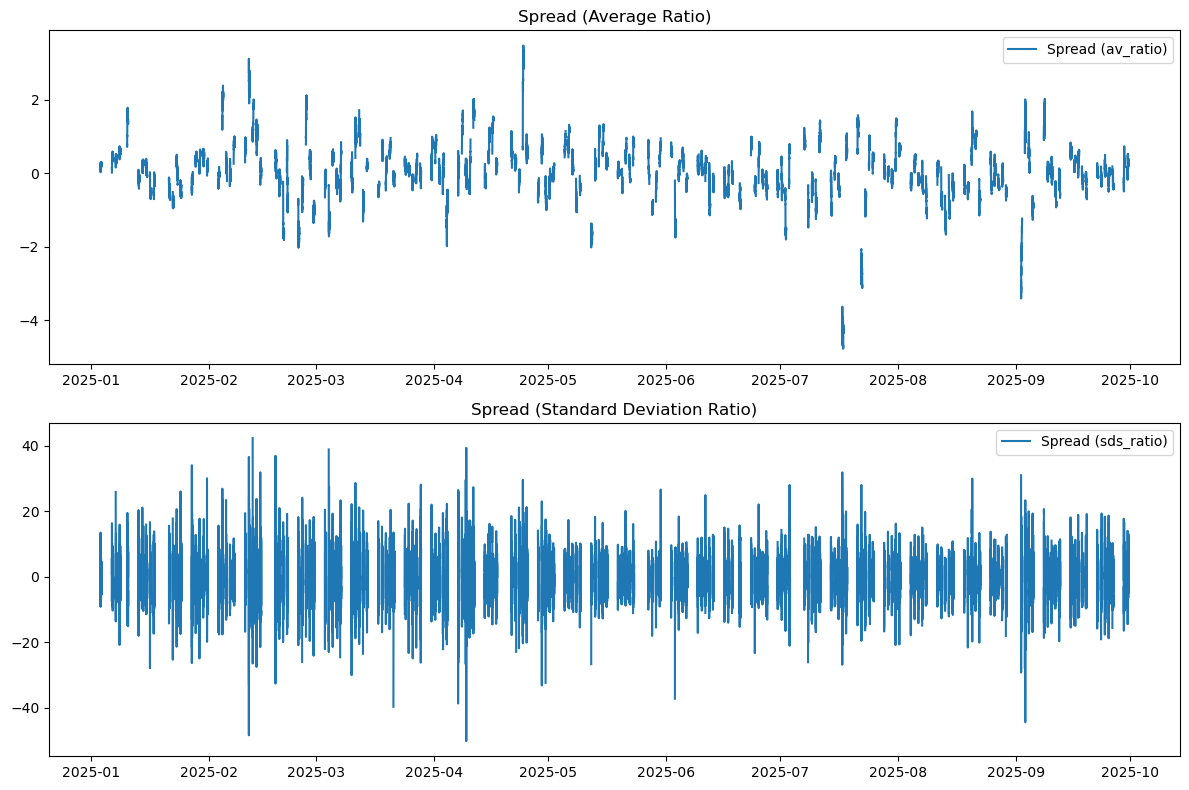

In [38]:
# plot both spreads in separate subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

axes[0].plot(dataUSA_2.index, 
             dataUSA_2["spread_avratio"], 
             label = "Spread (av_ratio)")
axes[0].set_title("Spread (Average Ratio)")
axes[0].legend()

axes[1].plot(dataUSA_2.index, 
             dataUSA_2["spread_sdsratio"], 
             label = "Spread (sds_ratio)")
axes[1].set_title("Spread (Standard Deviation Ratio)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
# we assume that spread mean reverts to 0

# lets apply the volatility breakout model

# first we need to calculate the standard deviation of the spreads
# let's use rolling window of 120 minutes (2 hours)

dataUSA_2["std_spread_avratio"] = dataUSA_2["spread_avratio"].rolling(window=120).std()
dataUSA_2["std_spread_sdsratio"] = dataUSA_2["spread_sdsratio"].rolling(window=120).std()

# lets put missings whenever KO price is missing
# (PEP price should be missing in the same moments)

dataUSA_2.loc[dataUSA_2["close_KO"].isna(), ["std_spread_avratio", "std_spread_sdsratio"]] = np.nan


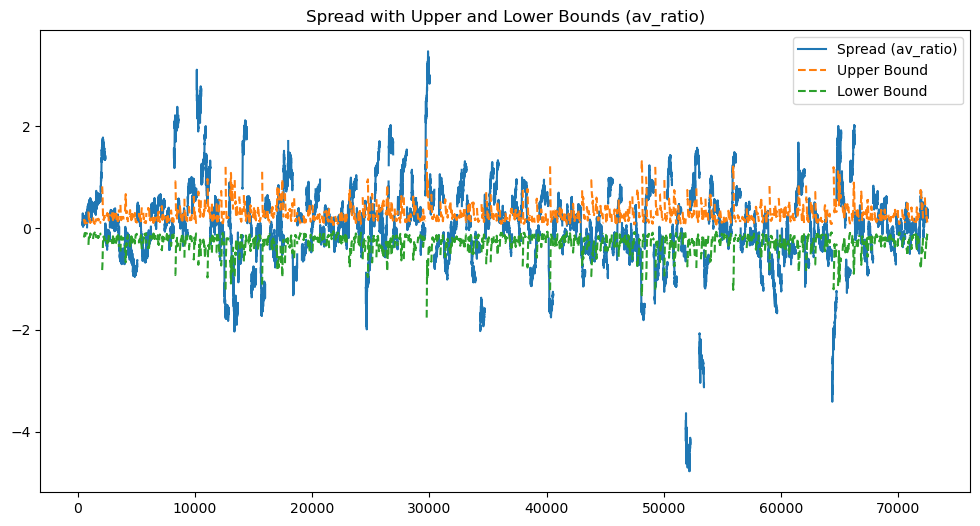

In [40]:
# applying a volatility breakout model
# sample upper and lower bounds for spreads
# for a volatility multiplier of 3
# (here we put the upper and lower band along zero)

dataUSA_2["upper_bound_avratio"] = 3 * dataUSA_2["std_spread_avratio"]
dataUSA_2["lower_bound_avratio"] = -3 * dataUSA_2["std_spread_avratio"]

# lets see how it looks like
# ignoring time dimension for clarity

dataUSA_2_plot = dataUSA_2.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["spread_avratio"], 
         label="Spread (av_ratio)")
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["upper_bound_avratio"], 
         label="Upper Bound", linestyle='--')
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["lower_bound_avratio"], 
         label="Lower Bound", linestyle='--')
plt.title("Spread with Upper and Lower Bounds (av_ratio)")
plt.legend()
plt.show()  

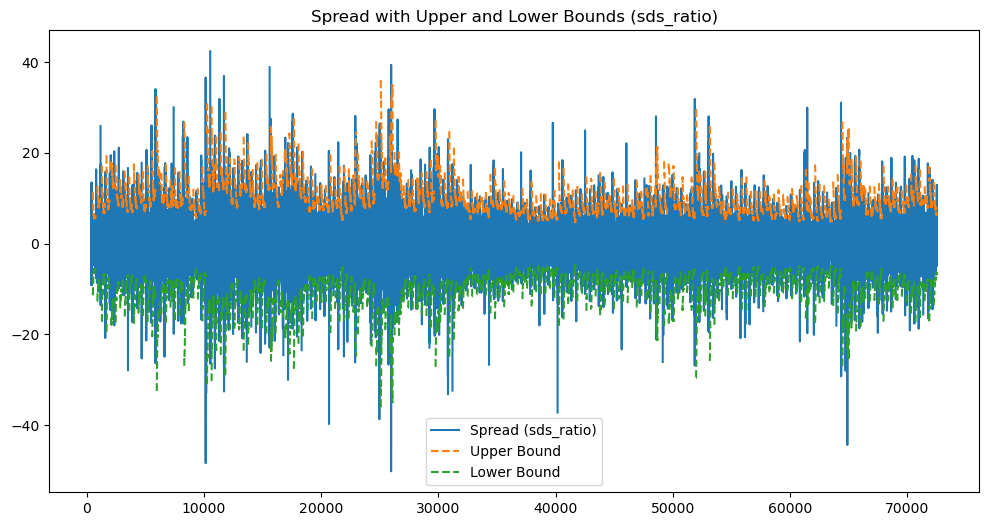

In [41]:
# the same for spread_sdsratio

dataUSA_2["upper_bound_sdsratio"] = 3 * dataUSA_2["std_spread_sdsratio"]
dataUSA_2["lower_bound_sdsratio"] = -3 * dataUSA_2["std_spread_sdsratio"]

# lets see how it looks like
# ignoring time dimension for clarity
dataUSA_2_plot = dataUSA_2.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["spread_sdsratio"], 
         label="Spread (sds_ratio)")
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["upper_bound_sdsratio"],
         label="Upper Bound", linestyle='--')
plt.plot(dataUSA_2_plot.index, 
         dataUSA_2_plot["lower_bound_sdsratio"],
         label="Lower Bound", linestyle='--')
plt.title("Spread with Upper and Lower Bounds (sds_ratio)")
plt.legend()
plt.show()

In [42]:
### position will be based on relation of the spread to volatility bands

# lets assume we do not trade within the first 15-mins of the day
# and exit all positions 15 minutes before the end of quotations

# lets create a pos_flat vector and fill it with 0s

pos_flat = np.zeros(len(dataUSA_2))

In [43]:
# we do not trade within the first quarter (9:31-9:45) 
# but also before that time since midnight

pos_flat[dataUSA_2.index.time <= pd.to_datetime("9:45").time()] = 1

# and last quarter of the session (15:46-16:00)
# but also after this time until midnight

pos_flat[dataUSA_2.index.time >= pd.to_datetime("15:46").time()] = 1

# !!! there are no weekends in our data, so we do not need 
# to control for that in pos_flat

pd.Series(pos_flat).value_counts()

0.0    66960
1.0     5580
Name: count, dtype: int64

In [53]:
# lets use the positionVB() function known from previous labs
# to calculate the position based on spread_avratio

from functions.position_VB import positionVB

dataUSA_2["pos_avratio"] = positionVB(signal = dataUSA_2["spread_avratio"],
                                      lower = dataUSA_2["lower_bound_avratio"],
                                      upper = dataUSA_2["upper_bound_avratio"],
                                      pos_flat = pos_flat,
                                      # IMPORTANT !!!!
                                      strategy = "mr")

dataUSA_2["pos_avratio"].value_counts()

C:\Users\LO79RS\HFD\8\functions\position_VB.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if not np.isnan(signal[i-1]) and not np.isnan(upper[i-1]) and not np.isnan(lower[i-1]):
C:\Users\LO79RS\HFD\8\functions\position_VB.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if signal[i-1] > upper[i-1]:
C:\Users\LO79RS\HFD\8\functions\position_VB.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif signal[i-1] < lower[i-1

pos_avratio
 0.0    33544
-1.0    21403
 1.0    17593
Name: count, dtype: int64

In [54]:
# lets create a vector of the number of transactions

dataUSA_2["n_trans_avratio"] = np.abs(np.diff(dataUSA_2["pos_avratio"], prepend = 0))

In [55]:
# next we calculate the gross P&L from the strategy
# for every minute 
# we multiply the position by the return of the spread

# gross PnL = position * (dP_KO - ratio * dP_PEP) 

dataUSA_2["pnl_gross_avratio"] = dataUSA_2["pos_avratio"] * (dataUSA_2["close_KO"].diff() - dataUSA_2["av_ratio"] * dataUSA_2["close_PEP"].diff())

In [56]:
# Lets assume the trading cost on the level of 5 bpts (0.05%) per transaction

# check its value based on average closing prices
# during the analysed period

trcost_KO = round(dataUSA_close["close_KO"].mean() * 0.0005, 2)
trcost_PEP = round(dataUSA_close["close_PEP"].mean() * 0.0005, 2)

print(f"Trading cost per transaction for KO: {trcost_KO:.2f} USD")
print(f"Trading cost per transaction for PEP: {trcost_PEP:.2f} USD")

Trading cost per transaction for KO: 0.03 USD
Trading cost per transaction for PEP: 0.07 USD


In [57]:
# pnl after  costs

# !!! REMEMBER that we trade one unit of KO and av_ratio units of PEP
# AND there is NO minus "-" in the costs - they are always positive !!!

dataUSA_2["pnl_net_avratio"] = dataUSA_2["pnl_gross_avratio"] - dataUSA_2["n_trans_avratio"] * (trcost_KO + dataUSA_2["av_ratio"] * trcost_PEP)

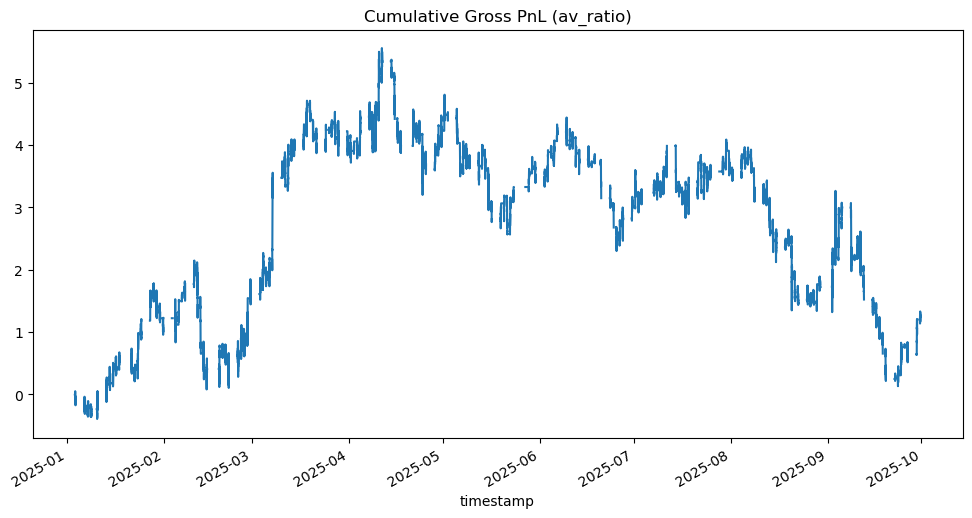

In [58]:
# lets calculate and plot cumulative gross PnL
# without adding a new column to the data

dataUSA_2["pnl_gross_avratio"].cumsum().plot(figsize=(12,6), 
                                             title="Cumulative Gross PnL (av_ratio)")
plt.show()

# positive, but not very impressive...

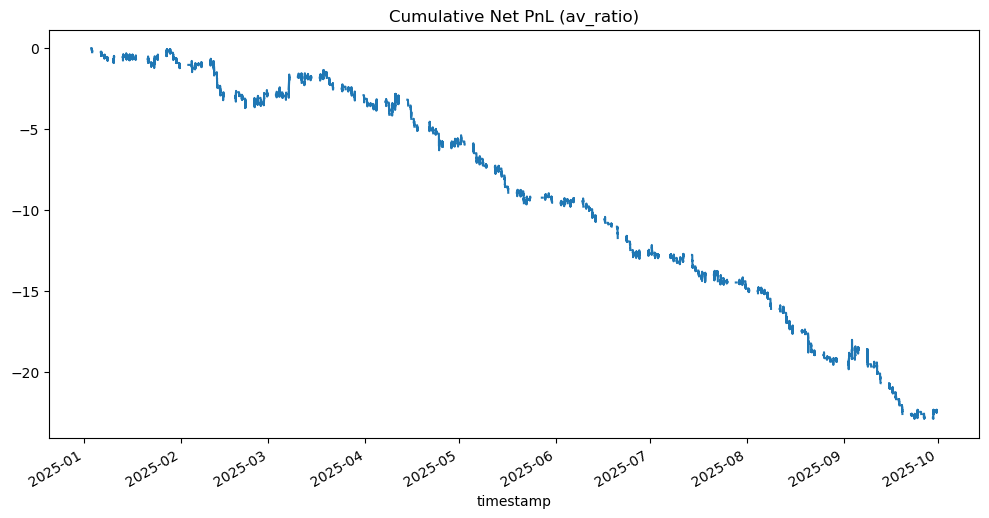

In [59]:
# what about cummulative net PnL?

dataUSA_2["pnl_net_avratio"].cumsum().plot(figsize=(12,6), 
                                           title="Cumulative Net PnL (av_ratio)")
plt.show()

# as expected :)

In [60]:
# lets do a comparison within a loop for spread_avratio and spread_sdsratio

def mySR(x, scale):
    return np.sqrt(scale) * np.nanmean(x) / np.nanstd(x)

volat_sd_parameters = [60, 90, 120, 150, 180]
m_parameters = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]

# create a dataframe to store results
summary_all_KO_PEP = pd.DataFrame()

for volat_sd in volat_sd_parameters:
    for m in m_parameters:
        print(f"volat_sd: {volat_sd}, m: {m}")

        # calculate teh elements of the strategy
        close_KO = dataUSA_2["close_KO"]
        close_PEP = dataUSA_2["close_PEP"]

        # spread based on average ratio
        signal_avratio = close_KO - (dataUSA_2["av_ratio"] * close_PEP)
        std_spread_avratio = signal_avratio.rolling(window=volat_sd).std()
        upper_bound_avratio = m * std_spread_avratio
        lower_bound_avratio = -m * std_spread_avratio
        # position
        pos_avratio = positionVB(signal = signal_avratio,
                                lower = lower_bound_avratio,
                                upper = upper_bound_avratio,
                                pos_flat = pos_flat,
                                strategy = "mr")
        # number of transactions
        n_trans_avratio = np.abs(np.diff(pos_avratio, prepend = 0))
        # convert to pd.Series and set the index
        n_trans_avratio = pd.Series(n_trans_avratio, index=dataUSA_2.index)

        # gross and net PnL
        pnl_gross_avratio = pos_avratio * (dataUSA_2["close_KO"].diff() - dataUSA_2["av_ratio"] * dataUSA_2["close_PEP"].diff())
        pnl_net_avratio = pnl_gross_avratio - n_trans_avratio * (trcost_KO + dataUSA_2["av_ratio"] * trcost_PEP)

        # spread based on standard deviation ratio
        signal_sdsratio = dataUSA_2["spread_sdsratio"]
        std_spread_sdsratio = signal_sdsratio.rolling(window=volat_sd).std()
        upper_bound_sdsratio = m * std_spread_sdsratio
        lower_bound_sdsratio = -m * std_spread_sdsratio
        # position
        pos_sdsratio = positionVB(signal = signal_sdsratio,
                                lower = lower_bound_sdsratio,
                                upper = upper_bound_sdsratio,
                                pos_flat = pos_flat,
                                strategy = "mr")
        
        # number of transactions
        n_trans_sdsratio = np.abs(np.diff(pos_sdsratio, prepend = 0))
        # convert to pd.Series and set the index
        n_trans_sdsratio = pd.Series(n_trans_sdsratio, index=dataUSA_2.index)

        # !!!!! signal is based on returns, but PnL on prices !!!!
        pnl_gross_sdsratio = pos_sdsratio * (dataUSA_2["close_KO"].diff() - dataUSA_2["sds_ratio"] * dataUSA_2["close_PEP"].diff())
        pnl_net_sdsratio = pnl_gross_sdsratio - n_trans_sdsratio * (trcost_KO + dataUSA_2["sds_ratio"] * trcost_PEP)

        # aggregate to daily
        pnl_gross_avratio_daily = pnl_gross_avratio.resample("D").sum().dropna()
        pnl_gross_sdsratio_daily = pnl_gross_sdsratio.resample("D").sum().dropna()
        pnl_net_avratio_daily = pnl_net_avratio.resample("D").sum().dropna()
        pnl_net_sdsratio_daily = pnl_net_sdsratio.resample("D").sum().dropna()
        n_trans_avratio_daily = n_trans_avratio.resample("D").sum().dropna()
        n_trans_sdsratio_daily = n_trans_sdsratio.resample("D").sum().dropna()

        # calculate summary measures
        gross_SR_avratio = mySR(pnl_gross_avratio_daily, scale = 252)
        net_SR_avratio = mySR(pnl_net_avratio_daily, scale = 252)
        gross_PnL_avratio = pnl_gross_avratio_daily.sum()
        net_PnL_avratio = pnl_net_avratio_daily.sum()
        av_daily_ntrans_avratio = n_trans_avratio_daily.mean()
        
        gross_SR_sdsratio = mySR(pnl_gross_sdsratio_daily, scale = 252)
        net_SR_sdsratio = mySR(pnl_net_sdsratio_daily, scale = 252)
        gross_PnL_sdsratio = pnl_gross_sdsratio_daily.sum()
        net_PnL_sdsratio = pnl_net_sdsratio_daily.sum()
        av_daily_ntrans_sdsratio = n_trans_sdsratio_daily.mean()
        
        # Collect the necessary results into one object
        summary = pd.DataFrame({
                'volat_sd': volat_sd,
                'm': m,
                'period': '2025Q1-Q3',
                'gross_SR_avratio': gross_SR_avratio,
                'net_SR_avratio': net_SR_avratio,
                'gross_PnL_avratio': gross_PnL_avratio,
                'net_PnL_avratio': net_PnL_avratio,
                'av_daily_ntrans_avratio': av_daily_ntrans_avratio,
                'gross_SR_sdsratio': gross_SR_sdsratio,
                'net_SR_sdsratio': net_SR_sdsratio,
                'gross_PnL_sdsratio': gross_PnL_sdsratio,
                'net_PnL_sdsratio': net_PnL_sdsratio,
                'av_daily_ntrans_sdsratio': av_daily_ntrans_sdsratio
                }, index=[0])

        # Append the results to the summary
        summary_all_KO_PEP = pd.concat([summary_all_KO_PEP, 
                                        summary], 
                                    ignore_index = True)

# it takes about 3 minutes to run

volat_sd: 60, m: 0.5


C:\Users\LO79RS\HFD\8\functions\position_VB.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if not np.isnan(signal[i-1]) and not np.isnan(upper[i-1]) and not np.isnan(lower[i-1]):
C:\Users\LO79RS\HFD\8\functions\position_VB.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if signal[i-1] > upper[i-1]:
C:\Users\LO79RS\HFD\8\functions\position_VB.py:34: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if signal[i-1] > lower[i-1]:

volat_sd: 60, m: 1
volat_sd: 60, m: 1.5
volat_sd: 60, m: 2
volat_sd: 60, m: 2.5
volat_sd: 60, m: 3
volat_sd: 60, m: 3.5
volat_sd: 90, m: 0.5
volat_sd: 90, m: 1
volat_sd: 90, m: 1.5
volat_sd: 90, m: 2
volat_sd: 90, m: 2.5
volat_sd: 90, m: 3
volat_sd: 90, m: 3.5
volat_sd: 120, m: 0.5
volat_sd: 120, m: 1
volat_sd: 120, m: 1.5
volat_sd: 120, m: 2
volat_sd: 120, m: 2.5
volat_sd: 120, m: 3
volat_sd: 120, m: 3.5
volat_sd: 150, m: 0.5
volat_sd: 150, m: 1
volat_sd: 150, m: 1.5
volat_sd: 150, m: 2
volat_sd: 150, m: 2.5
volat_sd: 150, m: 3
volat_sd: 150, m: 3.5
volat_sd: 180, m: 0.5
volat_sd: 180, m: 1
volat_sd: 180, m: 1.5
volat_sd: 180, m: 2
volat_sd: 180, m: 2.5
volat_sd: 180, m: 3
volat_sd: 180, m: 3.5


In [61]:
# lets import a function written by the lecturer
# to visualize the strategy results in a form of a heatmap
from functions.plot_heatmap import plot_heatmap

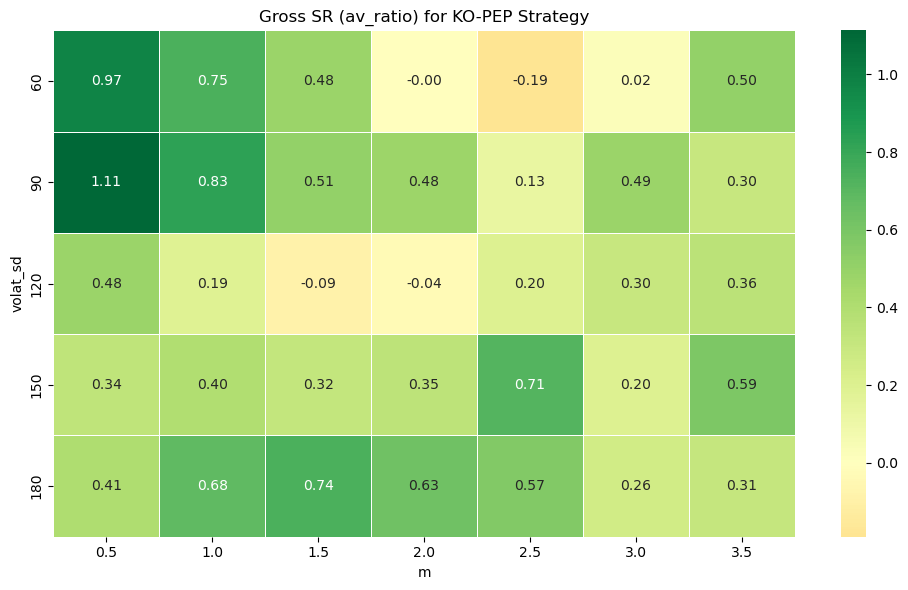

In [62]:
# and see the results on the heatmap graph

# gross SR - spread av_ratio
plot_heatmap(summary_all_KO_PEP, 
             value_col = "gross_SR_avratio", 
             index_col = "volat_sd", 
             columns_col = "m", 
             title = "Gross SR (av_ratio) for KO-PEP Strategy")

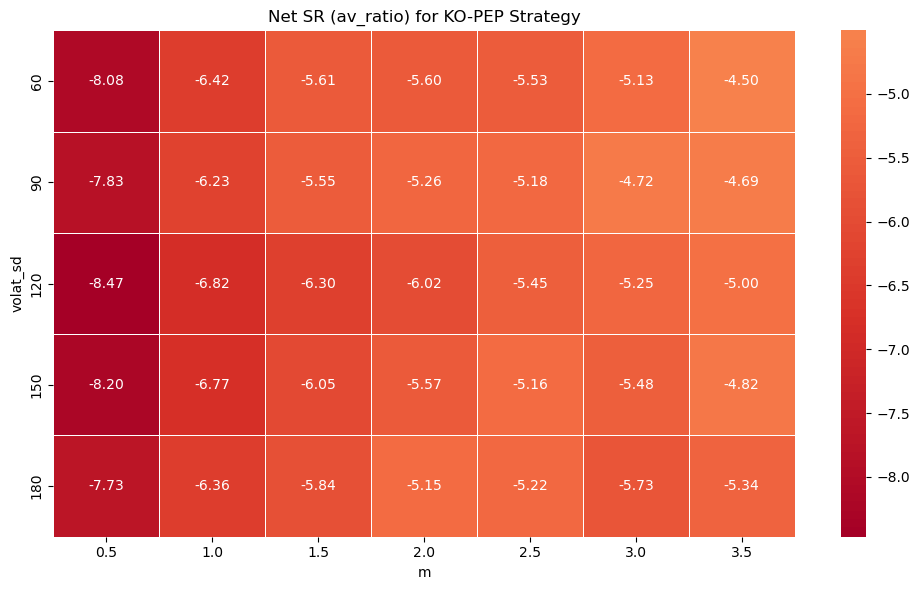

In [63]:
# net SR - spread av_ratio
plot_heatmap(summary_all_KO_PEP,
             value_col = "net_SR_avratio", 
             index_col = "volat_sd", 
             columns_col = "m", 
             title = "Net SR (av_ratio) for KO-PEP Strategy")

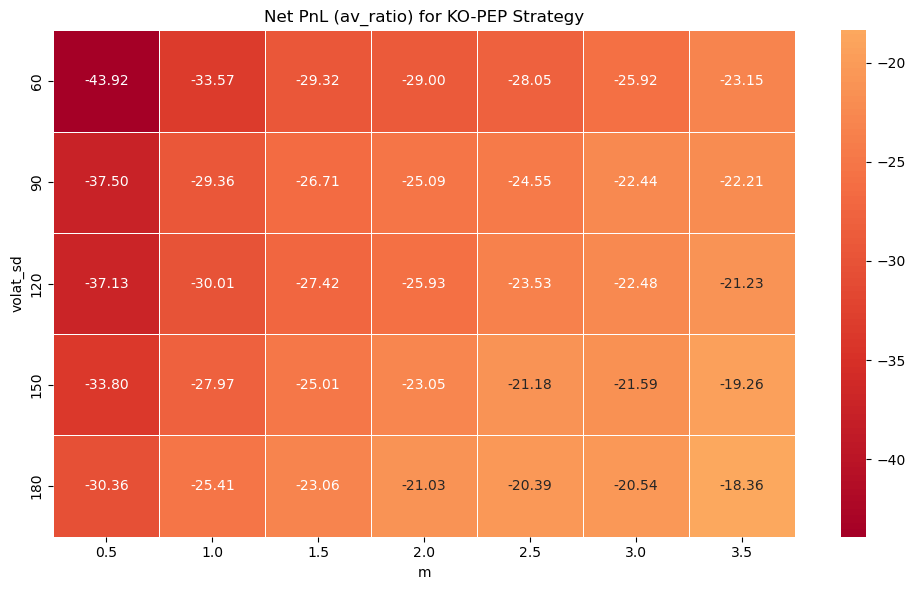

In [64]:
# net Pnl - spread av_ratio
plot_heatmap(summary_all_KO_PEP,
             value_col = "net_PnL_avratio", 
             index_col = "volat_sd", 
             columns_col = "m", 
             title = "Net PnL (av_ratio) for KO-PEP Strategy")

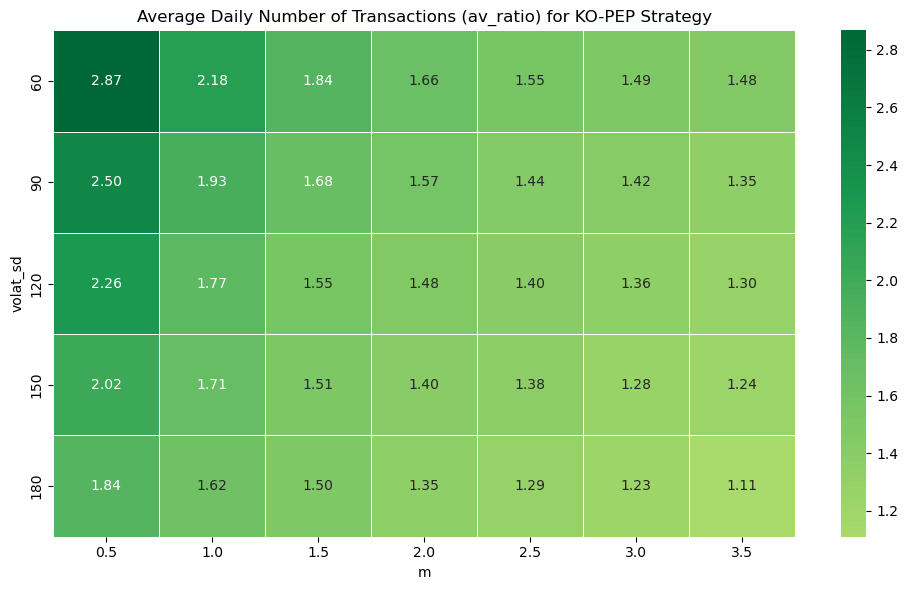

In [65]:
# average daily ntrans

plot_heatmap(summary_all_KO_PEP,
             value_col = "av_daily_ntrans_avratio",
             index_col = "volat_sd",
             columns_col = "m",
             title = "Average Daily Number of Transactions (av_ratio) for KO-PEP Strategy")

In [66]:
# here we assume that we trade every day

# lets save the results for the next labs, when we will
# apply some additional filtering rules

dataUSA_2.to_parquet("dataUSA_2_KO_PEP.parquet")
summary_all_KO_PEP.to_parquet("summary_all_KO_PEP.parquet")


# Exercises 8

# Exercise 8.1

* using `plot_heatmap()` function check profitability of strategies using spread_sdsratio
* for the best combination of parameters (in terms of net SR) prepare and plot the equity curve (gross and net cummulatve pnl)

In [84]:
# I prepare a minute-level dataset for AAPL–MSFT.

pair_AAPL_MSFT = pd.concat([
    dataUSA_close[["close_AAPL", "close_MSFT"]],
    dataUSA_r[["r_AAPL", "r_MSFT"]]
], axis=1).copy()

# As in the example, remove first and last 5 minutes of each trading session.
pair_AAPL_MSFT.loc[pair_AAPL_MSFT.between_time("9:31", "9:35").index] = np.nan
pair_AAPL_MSFT.loc[pair_AAPL_MSFT.between_time("15:56", "16:00").index] = np.nan

In [85]:
# Here I compute the daily SDS ratio = std(r_AAPL) / std(r_MSFT).

def daily_sds_ratio(x):
    return x["r_AAPL"].std() / x["r_MSFT"].std()

sds_daily = (
    pair_AAPL_MSFT
    .resample("D")
    .apply(daily_sds_ratio)
    .to_frame("sds_ratio")
    .dropna()
)

# Move each daily value to the next trading day at 9:31,
# imitating how the notebook handled KO–PEP.
daynames = sds_daily.index.day_name()
offsets = np.where(daynames == "Friday", "3D", "1D")
sds_daily.index = (
    sds_daily.index
    + pd.to_timedelta(offsets)
    + pd.Timedelta("9h31m")
)

In [83]:
# Merge SDS ratio into minute-level dataset.
pair2 = pair_AAPL_MSFT.merge(sds_daily, left_index=True, right_index=True, how="left")
pair2["sds_ratio"] = pair2["sds_ratio"].ffill()

# spread_sdsratio = r_AAPL − sds · r_MSFT
pair2["spread_sdsratio"] = pair2["r_AAPL"] - pair2["sds_ratio"] * pair2["r_MSFT"]

In [70]:
volat_sd_list = [60, 90, 120, 150, 180]
m_list = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]

In [86]:
summary_list = []
pnl_dict = {}

for vol in volat_sd_list:
    
    # rolling volatility of the spread (same idea as KO–PEP)
    std_spread = pair2["spread_sdsratio"].rolling(vol).std()
    
    for m in m_list:
        upper =  m * std_spread
        lower = -m * std_spread
        
        sig = pair2["spread_sdsratio"]
        pos = np.zeros(len(sig))
        
        # Basic mean-reversion logic:
        # Enter short when spread is too high, enter long when too low.
        # Close when it reverts to zero.
        for i in range(1, len(sig)):
            if np.isnan(sig.iloc[i]) or np.isnan(upper.iloc[i]):
                pos[i] = 0
                continue
            
            if pos[i-1] == 0:
                if sig.iloc[i] > upper.iloc[i]:
                    pos[i] = -1
                elif sig.iloc[i] < lower.iloc[i]:
                    pos[i] = 1
            else:
                if (pos[i-1] == 1 and sig.iloc[i] >= 0) or (pos[i-1] == -1 and sig.iloc[i] <= 0):
                    pos[i] = 0
                else:
                    pos[i] = pos[i-1]
        
        # number of transactions
        ntrans = np.abs(np.diff(pos, prepend=0))
        
        # gross PnL — spread_sdsratio is in bps → divide by 10,000
        spread_vals = sig.values
        gross_pnl = pos[:-1] * spread_vals[1:] / 10000.0
        gross_pnl = np.insert(gross_pnl, 0, 0)
        
    
        net_pnl = gross_pnl.copy()
        
        gross_pnl_s = pd.Series(gross_pnl, index=pair2.index)
        net_pnl_s   = pd.Series(net_pnl, index=pair2.index)
        ntrans_s    = pd.Series(ntrans, index=pair2.index)
        
        # daily aggregation
        daily_gross = gross_pnl_s.resample("D").sum()
        daily_net   = net_pnl_s.resample("D").sum()
        daily_ntr   = ntrans_s.resample("D").sum()
        
        # simple Sharpe ratio function
        def mySR(x):
            x = np.asarray(x)
            if np.nanstd(x) == 0: 
                return 0
            return np.sqrt(252) * np.nanmean(x) / np.nanstd(x)
        
        summary_list.append({
            "volat_sd": vol,
            "m": m,
            "gross_SR_sdsratio": mySR(daily_gross),
            "net_SR_sdsratio": mySR(daily_net),
            "gross_PnL_sdsratio": daily_gross.sum(),
            "net_PnL_sdsratio": daily_net.sum(),
            "av_daily_ntrans_sdsratio": daily_ntr.mean()
        })
        
        pnl_dict[(vol, m)] = {
            "gross": gross_pnl_s,
            "net": net_pnl_s
        }

summary_AAPL_MSFT = pd.DataFrame(summary_list)
summary_AAPL_MSFT.head()

,volat_sd,m,gross_SR_sdsratio,net_SR_sdsratio,gross_PnL_sdsratio,net_PnL_sdsratio,av_daily_ntrans_sdsratio
0,60,0.5,2.982816,2.982816,0.495039,0.495039,118.161765
1,60,1.0,2.989873,2.989873,0.411533,0.411533,75.382353
2,60,1.5,1.842484,1.842484,0.225361,0.225361,38.352941
3,60,2.0,0.854694,0.854694,0.093538,0.093538,16.066176
4,60,2.5,1.010757,1.010757,0.101052,0.101052,6.345588


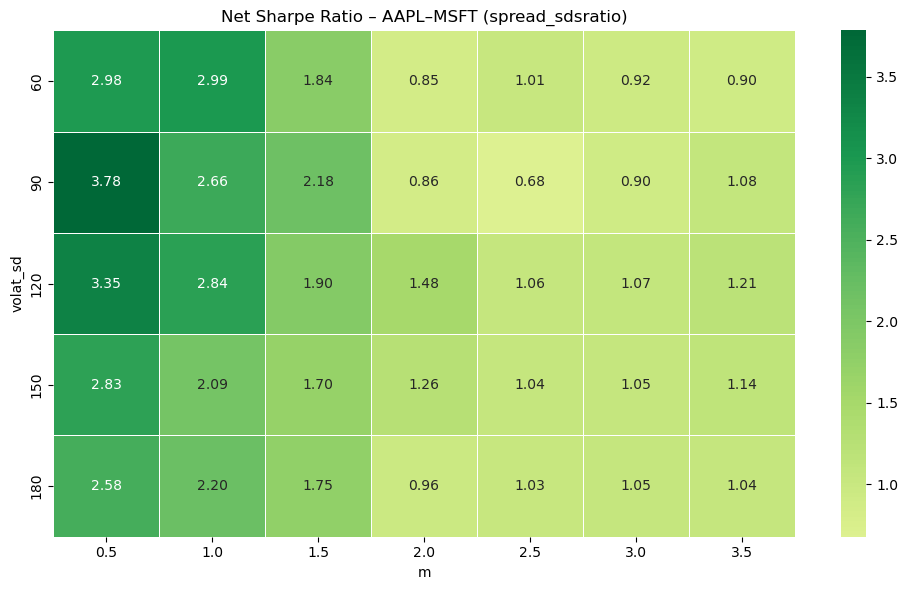

In [74]:
# Heatmap function
plot_heatmap(
    summary_AAPL_MSFT,
    value_col="net_SR_sdsratio",
    index_col="volat_sd",
    columns_col="m",
    title="Net Sharpe Ratio – AAPL–MSFT (spread_sdsratio)"
)

Best parameters for AAPL–MSFT:
volat_sd = 90
m        = 0.5
net SR   = 3.7835662222718853


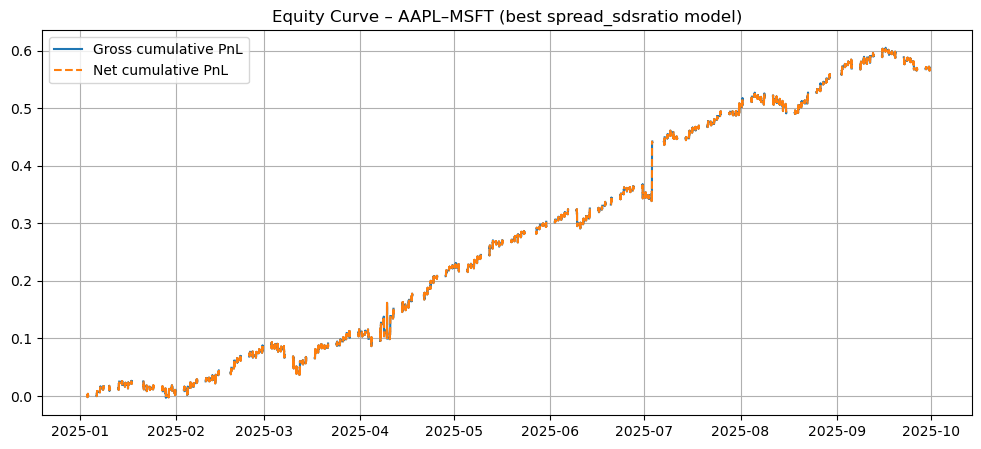

In [75]:
# find best parameter combination
best_row = summary_AAPL_MSFT.loc[
    summary_AAPL_MSFT["net_SR_sdsratio"].idxmax()
]

best_sd = int(best_row["volat_sd"])
best_m  = float(best_row["m"])

print("Best parameters for AAPL–MSFT:")
print("volat_sd =", best_sd)
print("m        =", best_m)
print("net SR   =", best_row['net_SR_sdsratio'])

# extract pnl series
best_gross = pnl_dict[(best_sd, best_m)]["gross"].cumsum()
best_net   = pnl_dict[(best_sd, best_m)]["net"].cumsum()

plt.figure(figsize=(12,5))
plt.plot(best_gross, label="Gross cumulative PnL")
plt.plot(best_net, label="Net cumulative PnL", linestyle="--")
plt.title("Equity Curve – AAPL–MSFT (best spread_sdsratio model)")
plt.grid(True)
plt.legend()
plt.show()

# Exercise 8.2

build and test a similar model for another pair of stocks (play with different parameter values and spread definition) - assume costs at the level of 5 bps


In [76]:
#I prepare a minute-level dataset for the GOOGL–META pair.

pair_GOOGL_META = pd.concat([
    dataUSA_close[["close_GOOGL", "close_META"]],
    dataUSA_r[["r_GOOGL", "r_META"]]
], axis=1).copy()

# Remove the first and last 5 minutes of each trading session
pair_GOOGL_META.loc[pair_GOOGL_META.between_time("9:31", "9:35").index] = np.nan
pair_GOOGL_META.loc[pair_GOOGL_META.between_time("15:56", "16:00").index] = np.nan

In [77]:
# Daily SDS ratio = std(r_GOOGL) / std(r_META)
# This is the same approach used in the KO–PEP and AAPL–MSFT exercises.

def daily_sds_ratio_GM(x):
    return x["r_GOOGL"].std() / x["r_META"].std()

sds_daily_GM = (
    pair_GOOGL_META
    .resample("D")
    .apply(daily_sds_ratio_GM)
    .to_frame("sds_ratio")
    .dropna()
)

# Move SDS ratio value to the next trading day at 9:31.
daynames = sds_daily_GM.index.day_name()
offsets = np.where(daynames == "Friday", "3D", "1D")

sds_daily_GM.index = (
    sds_daily_GM.index
    + pd.to_timedelta(offsets)
    + pd.Timedelta("9h31m")
)

In [78]:
pairGM = pair_GOOGL_META.merge(sds_daily_GM, left_index=True, right_index=True, how="left")
pairGM["sds_ratio"] = pairGM["sds_ratio"].ffill()

# spread_sdsratio = r_GOOGL − sds * r_META
pairGM["spread_sdsratio"] = pairGM["r_GOOGL"] - pairGM["sds_ratio"] * pairGM["r_META"]

In [79]:
volat_sd_list = [60, 90, 120, 150, 180]
m_list = [0.5, 1, 1.5, 2, 2.5, 3, 3.5]

In [80]:
summary_list_GM = []
pnl_dict_GM = {}
cost_bp = 5          # <-- cost required
cost_per_tr = cost_bp / 10000.0   # convert bps to return units

def mySR(x):
    x = np.asarray(x)
    if np.nanstd(x) == 0:
        return 0
    return np.sqrt(252) * np.nanmean(x) / np.nanstd(x)

for vol in volat_sd_list:
    
    std_spread = pairGM["spread_sdsratio"].rolling(vol).std()
    
    for m in m_list:
        
        upper =  m * std_spread
        lower = -m * std_spread
        
        sig = pairGM["spread_sdsratio"]
        pos = np.zeros(len(sig))
        
        # Mean-reversion logic: same style as 8.1
        for i in range(1, len(sig)):
            if np.isnan(sig.iloc[i]) or np.isnan(upper.iloc[i]):
                pos[i] = 0
                continue
            
            if pos[i-1] == 0:
                if sig.iloc[i] > upper.iloc[i]:
                    pos[i] = -1
                elif sig.iloc[i] < lower.iloc[i]:
                    pos[i] = 1
            else:
                # exit when spread returns to zero
                if (pos[i-1] == 1 and sig.iloc[i] >= 0) or (pos[i-1] == -1 and sig.iloc[i] <= 0):
                    pos[i] = 0
                else:
                    pos[i] = pos[i-1]
        
        ntrans = np.abs(np.diff(pos, prepend=0))
        spread_vals = sig.values
        
        gross_pnl = pos[:-1] * spread_vals[1:] / 10000.0
        gross_pnl = np.insert(gross_pnl, 0, 0)
        
        costs = ntrans * cost_per_tr
        net_pnl = gross_pnl - costs
        
        gross_s = pd.Series(gross_pnl, index=pairGM.index)
        net_s   = pd.Series(net_pnl, index=pairGM.index)
        ntr_s   = pd.Series(ntrans, index=pairGM.index)
        
        daily_gross = gross_s.resample("D").sum()
        daily_net   = net_s.resample("D").sum()
        daily_ntr   = ntr_s.resample("D").sum()
        
        summary_list_GM.append({
            "volat_sd": vol,
            "m": m,
            "gross_SR_sdsratio": mySR(daily_gross),
            "net_SR_sdsratio": mySR(daily_net),
            "gross_PnL_sdsratio": daily_gross.sum(),
            "net_PnL_sdsratio": daily_net.sum(),
            "av_daily_ntrans_sdsratio": daily_ntr.mean()
        })
        
        pnl_dict_GM[(vol, m)] = {
            "gross": gross_s,
            "net": net_s
        }

summary_GOOGL_META = pd.DataFrame(summary_list_GM)
summary_GOOGL_META.head()

,volat_sd,m,gross_SR_sdsratio,net_SR_sdsratio,gross_PnL_sdsratio,net_PnL_sdsratio,av_daily_ntrans_sdsratio
0,60,0.5,6.644674,-22.445941,1.141934,-15.024066,119.264706
1,60,1.0,6.340023,-21.645521,0.950239,-9.378761,76.316176
2,60,1.5,5.302275,-19.377657,0.630099,-4.514901,38.139706
3,60,2.0,3.102880,-13.341554,0.315040,-1.739460,15.352941
4,60,2.5,1.812398,-5.873150,0.171636,-0.580864,5.713235


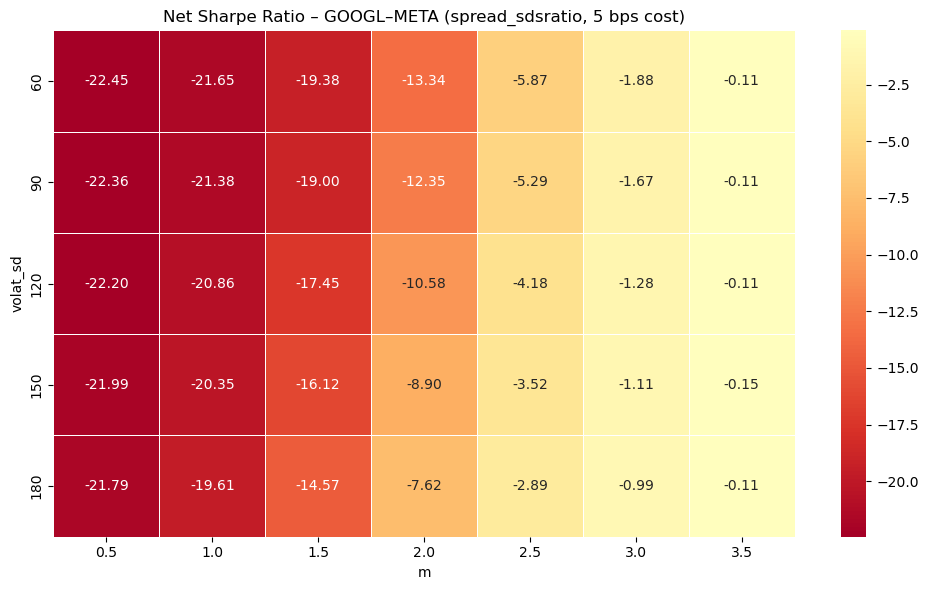

In [81]:
plot_heatmap(
    summary_GOOGL_META,
    value_col="net_SR_sdsratio",
    index_col="volat_sd",
    columns_col="m",
    title="Net Sharpe Ratio – GOOGL–META (spread_sdsratio, 5 bps cost)"
)

Best parameters for GOOGL–META (with 5 bps cost):
volat_sd = 180
m        = 3.5
net SR   = -0.10796138233162408


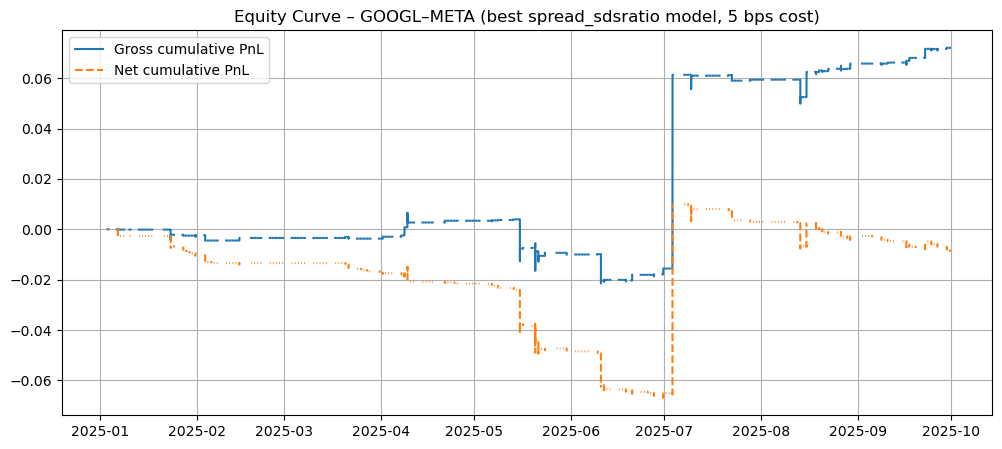

In [82]:
best_row_GM = summary_GOOGL_META.loc[
    summary_GOOGL_META["net_SR_sdsratio"].idxmax()
]

best_sd_GM = int(best_row_GM["volat_sd"])
best_m_GM  = float(best_row_GM["m"])

print("Best parameters for GOOGL–META (with 5 bps cost):")
print("volat_sd =", best_sd_GM)
print("m        =", best_m_GM)
print("net SR   =", best_row_GM["net_SR_sdsratio"])

best_gross_GM = pnl_dict_GM[(best_sd_GM, best_m_GM)]["gross"].cumsum()
best_net_GM   = pnl_dict_GM[(best_sd_GM, best_m_GM)]["net"].cumsum()

plt.figure(figsize=(12,5))
plt.plot(best_gross_GM, label="Gross cumulative PnL")
plt.plot(best_net_GM, label="Net cumulative PnL", linestyle="--")
plt.title("Equity Curve – GOOGL–META (best spread_sdsratio model, 5 bps cost)")
plt.grid(True)
plt.legend()
plt.show()

The exercises show that the spread_sdsratio strategy is pair-dependent:
it works very well for some stock pairs (e.g., AAPL–MSFT) but fails for others (e.g., GOOGL–META).
This highlights the importance of pair selection and proper parameter tuning when designing statistical arbitrage strategies.